# Pontificia Universidad Católica de Chile

# EPG4001 Aprendizaje Supervisado

# Material complementario clase 3

# MIAApSu.pdf

**Dr. Jorge Luis Bazán**  
**jlbazan@uc.cl**


# 1. Carga de librerías

Las librerías a utilizar para los procedimientos son las siguientes:


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import io
import shutil
import subprocess

from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report

def cargar_rdataset(nombre, paquete):
    try:
        return sm.datasets.get_rdataset(nombre, paquete).data
    except Exception as py_err:
        if shutil.which("Rscript") is None:
            raise RuntimeError(
                f"No se pudo cargar {paquete}::{nombre} con Python y Rscript no está disponible."
            ) from py_err

        r_code = f'''
        pkg <- "{paquete}"
        ds <- "{nombre}"
        if (pkg != "datasets" && !requireNamespace(pkg, quietly = TRUE)) {{
          install.packages(pkg, repos = "https://cloud.r-project.org")
        }}
        data(list = ds, package = pkg, envir = environment())
        write.csv(as.data.frame(get(ds)), row.names = FALSE)
        '''
        res = subprocess.run(["Rscript", "-e", r_code], capture_output=True, text=True)
        if res.returncode != 0:
            raise RuntimeError(
                f"No se pudo cargar {paquete}::{nombre} con Python ni con R.\n{res.stderr}"
            ) from py_err
        return pd.read_csv(io.StringIO(res.stdout))

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# 2. Gráfica funciones de enlace sección 2.2

El objetivo es visualizar el comportamiento de las distintas funciones de enlace para el modelo lineal generalizado cuya respuesta es binaria. Primero definimos los rangos entre los que se moverá la función.


In [ ]:
# Valores del eje x
x = np.linspace(-5, 5, 500)

Luego definimos las funciones Logit, Probit y CLogLog.


In [ ]:
# Funciones de enlace inversas
logit = 1 / (1 + np.exp(-x))          # Logit
probit = stats.norm.cdf(x)            # Probit
cloglog = 1 - np.exp(-np.exp(x))      # Complementary log-log

Luego realizamos el gráfico respectivo.


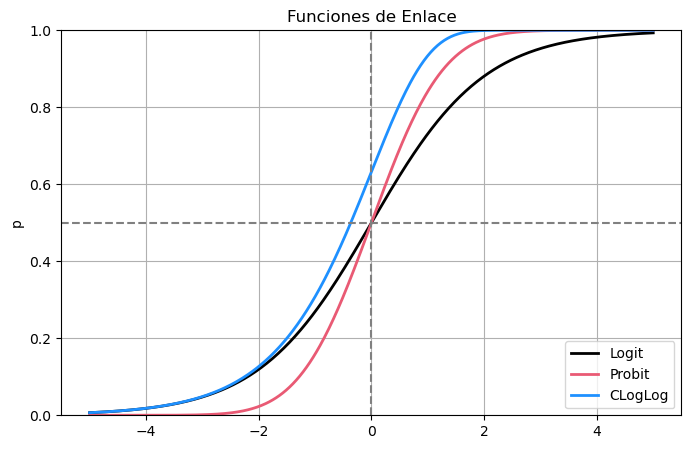

In [ ]:
# Graficamos la función logit primero
fig, ax = plt.subplots()
ax.plot(x, logit, linewidth=2, color="black", label="Logit")

# Agregamos las funciones probit y cloglog
ax.plot(x, probit, color="#E95A74", linewidth=2, label="Probit")
ax.plot(x, cloglog, color="dodgerblue", linewidth=2, label="CLogLog")

# Agregamos líneas punteadas que indican la probabilidad 0.5.
ax.axvline(0, linestyle="--", color="gray")
ax.axhline(0.5, linestyle="--", color="gray")

ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.set_ylabel("p")
ax.set_title("Funciones de Enlace")
ax.legend(loc="lower right", frameon=True)
plt.show()

Es importante notar que cada función de enlace tiene su particularidad para datos binarios. Se observa que tanto la función de enlace Logit como la Probit resultan ser simétricas y centradas en el punto $(0,0.5)$, con la diferencia de que la función de enlace Logit presenta colas un poco más pesadas que la función Probit. Por otro lado, la función de enlace CLogLog presenta una asimetría que permite que la función alcance valores positivos más rápidamente que las mencionadas anteriormente.


# 3. Aplicación sección 2.7

Realizaremos una regresión logística para modelar la variable *chd* en función de *cigs*. Primero cargamos los datos.


In [ ]:
# Base wcgs, disponible originalmente en la librería faraway de R.
data = cargar_rdataset("wcgs", "faraway")
data.head()

,age,height,weight,sdp,dbp,chol,behave,cigs,dibep,chd,typechd,timechd,arcus
0,49,73,150,110,76,225.0,A2,25,A,no,none,1664,absent
1,42,70,160,154,84,177.0,A2,20,A,no,none,3071,present
2,42,69,160,110,78,181.0,B3,0,B,no,none,3071,absent
3,41,68,152,124,78,132.0,B4,20,B,no,none,3064,absent
4,59,70,150,144,86,255.0,B3,20,B,yes,infdeath,1885,present


## 3.1 Regresión Logística simple

Los resultados mediante un modelo logístico son los siguientes:


In [ ]:
modelo = smf.glm(
    "chd ~ cigs",
    data=data,
    family=sm.families.Binomial(link=sm.families.links.Logit()),
).fit()

Luego analizamos los resultados de la estimación con la siguiente sentencia.


In [ ]:
print(modelo.summary())

                    Generalized Linear Model Regression Results                    
Dep. Variable:     ['chd[no]', 'chd[yes]']   No. Observations:                 3154
Model:                                 GLM   Df Residuals:                     3152
Model Family:                     Binomial   Df Model:                            1
Link Function:                       Logit   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -874.98
Date:                     Mon, 06 Jul 2026   Deviance:                       1750.0
Time:                             09:03:32   Pearson chi2:                 3.14e+03
No. Iterations:                          6   Pseudo R-squ. (CS):           0.009867
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
In

Se observan los valores de $\hat{\beta_0}$ y $\hat{\beta_1}$, los cuales son aproximadamente $-2.742160$ y $0.0232220$, respectivamente.

Notar que en este caso el modelo de regresión logística indica que la variable *cigs* tiene un efecto estadísticamente significativo sobre la probabilidad de que ocurra *chd*, con un valor $p=9.22\times 10^{-09}\approx 0$, lo que permite rechazar la hipótesis nula al 5%.

El modelo de regresión logística quedaría expresado de la siguiente forma:

\begin{equation}
P(\text{chd}=\text{Yes} \mid \text{cigs}) =
\frac{e^{-2.742160 + 0.023220 \cdot \text{cigs}}}
{1 + e^{-2.742160 + 0.023220 \cdot \text{cigs}}}
\end{equation}


## 3.2 Cálculo de Odds

El odd representa una razón de probabilidades, es decir, nos indica qué tanto aumenta o disminuye la probabilidad de ocurrencia de nuestra variable respuesta cuando aumentamos en una unidad la variable explicativa.

\begin{equation}
\text{odd}=e^{\hat{\beta_0}}\cdot e^{\hat{\beta_1}\cdot x}
\end{equation}

En este caso, si $x$ aumenta en una unidad:

\begin{align}
\operatorname{odd}(x+1) 
&= e^{\beta_0+\beta_1(x+1)}\\
&= e^{\beta_0+\beta_1x+\beta_1}\\
&= e^{\beta_0+\beta_1x}e^{\beta_1}\\
&= \operatorname{odd}(x)e^{\beta_1}
\end{align}

Por tanto:

\begin{equation}
\frac{\text{odd}(x+1)}{\text{odd}(x)}
=
e^{\beta_1}
\end{equation}

Si el valor es mayor a 1, entonces el riesgo de que ocurra el evento es mayor; si es menor a 1, entonces el riesgo de que ocurra el evento es menor.


In [ ]:
# Extrae la exponencial de los coeficientes
np.exp(modelo.params)

Intercept    15.520465
cigs          0.977048
dtype: float64

In [ ]:
# Pasamos a numérico para solo tener el valor asociado a cigs
float(np.exp(modelo.params["cigs"]))

0.9770476934038548

Esto indica que, por cada unidad de aumento en la variable *cigs*, el odds de que ocurra la variable *chd* se multiplica por $e^{\hat\beta_1}$. En otras palabras, el odds aumenta aproximadamente un 2.35% por cada cigarrillo adicional.


# 4. Regresión Logística en Default data

El objetivo es predecir el cumplimiento o incumplimiento de la deuda de los clientes en función de las variables explicativas.


In [ ]:
# Base Default, disponible originalmente en la librería ISLR de R.
datos1 = cargar_rdataset("Default", "ISLR")

datos1.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [ ]:
# Estadísticas descriptivas de las variables de la base de datos
datos1.describe(include="all")

,default,student,balance,income
count,10000,10000,10000.000000,10000.000000
unique,2,2,NaN,NaN
top,No,No,NaN,NaN
freq,9667,7056,NaN,NaN
mean,NaN,NaN,835.374886,33516.981876
std,NaN,NaN,483.714985,13336.639563
min,NaN,NaN,0.000000,771.967729
25%,NaN,NaN,481.731105,21340.462903
50%,NaN,NaN,823.636973,34552.644802
75%,NaN,NaN,1166.308386,43807.729272


In [ ]:
# Variable binaria para los modelos logísticos en Python.
datos1 = datos1.copy()
datos1["default_yes"] = (datos1["default"] == "Yes").astype(int)
datos1.head()

,default,student,balance,income,default_yes
0,No,No,729.526495,44361.625074,0
1,No,Yes,817.180407,12106.134700,0
2,No,No,1073.549164,31767.138947,0
3,No,No,529.250605,35704.493935,0
4,No,No,785.655883,38463.495879,0


## 4.1 Regresión logística simple

Estudiaremos el cumplimiento o incumplimiento de la deuda de los clientes (*default*) en función del ingreso de los clientes (*income*), utilizando un modelo logístico.


In [ ]:
modelo_1 = smf.glm(
    "default_yes ~ income",
    data=datos1,
    family=sm.families.Binomial(link=sm.families.links.Logit()),
).fit()

Luego analizamos los resultados de la estimación con la siguiente sentencia.


In [ ]:
print(modelo_1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            default_yes   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9998
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1458.3
Date:                Mon, 06 Jul 2026   Deviance:                       2916.7
Time:                        09:03:34   Pearson chi2:                 1.00e+04
No. Iterations:                     6   Pseudo R-squ. (CS):          0.0003962
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.0941      0.146    -21.156      0.0

Notar que en este caso el modelo de regresión logística indica que la variable *income* tiene un efecto estadísticamente significativo sobre la probabilidad de que ocurra el evento de interés (variable *default*), con un valor p cercano a 0.0471, lo que permite rechazar la hipótesis nula al 5%.

El modelo de regresión logística quedaría expresado de la siguiente forma:

\begin{equation}
P(\text{default}=\text{Yes} \mid \text{income}) =
\frac{e^{-3.094 - 0.00000835 \cdot \text{income}}}
{1 + e^{-3.094 - 0.00000835 \cdot \text{income}}}
\end{equation}

En esta línea, si por ejemplo quisiéramos realizar una predicción de incumplimiento o cumplimiento de deuda para clientes con un ingreso de $40{,}000$, reemplazando en nuestro modelo el resultado sería el siguiente:

\begin{equation}
\hat{P}(\text{default}=\text{Yes} \mid \text{income}) =
\frac{e^{-3.094 - 0.00000835 \cdot 40000}}
{1 + e^{-3.094 - 0.00000835 \cdot 40000}}=
\frac{e^{-3.428}}{1 + e^{-3.428}}=0.0314
\end{equation}

Lo que nos indica que para un ingreso de $40{,}000$, la probabilidad estimada de default es aproximadamente 3.14%.


In [ ]:
# Predicción para income = 40000
modelo_1.predict(pd.DataFrame({"income": [40000]}))

0    0.031424
dtype: float64

## 4.2 Regresión logística múltiple

Estudiaremos el cumplimiento o incumplimiento de la deuda de los clientes (*default*) en función del ingreso de los clientes (*income*), saldo promedio en su tarjeta de crédito (*balance*) y condición de estudiante (*student*), utilizando un modelo logístico.


In [ ]:
modelo_2 = smf.glm(
    "default_yes ~ income + C(student) + balance",
    data=datos1,
    family=sm.families.Binomial(link=sm.families.links.Logit()),
).fit()

Luego analizamos los resultados de la estimación con la siguiente sentencia.


In [ ]:
print(modelo_2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            default_yes   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9996
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -785.77
Date:                Mon, 06 Jul 2026   Deviance:                       1571.5
Time:                        09:03:34   Pearson chi2:                 7.00e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1262
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           -10.8690      0.49

Es posible observar que la variable *balance* es altamente significativa ($p < 2\times 10^{-16}$). Este resultado sugiere que *balance* es una variable altamente explicativa para el modelo.

Por otro lado, la variable *studentYes* también resulta significativa al 1% ($p = 0.00619$).

Adicionalmente, al incluir el resto de covariables se observa que la variable *income* no es estadísticamente significativa ($p = 0.7115$), por lo que no existe evidencia suficiente para afirmar que el ingreso tenga un efecto sobre la probabilidad de *default*.

También queda en evidencia que tanto la devianza residual como el AIC en este caso disminuyen considerablemente con respecto al modelo con la variable *income* como único predictor, lo cual indica una mejora sustancial en la predicción de la probabilidad de incumplimiento de la deuda.

\begin{equation}
P(\text{default}=\text{Yes} \mid \vec{X}) =
\frac{e^{-10.87 - 0.6468 \cdot \text{studentYes} + 0.005737 \cdot \text{balance} + 0.000003033 \cdot \text{income}}}
{1 + e^{-10.87 - 0.6468 \cdot \text{studentYes} + 0.005737 \cdot \text{balance} + 0.000003033 \cdot \text{income}}}
\end{equation}


## 4.2.1 Curva ROC

Para el modelo con todas las covariables como predictores, realizamos el cálculo de la curva ROC para buscar el punto de corte óptimo que maximice la sensibilidad y especificidad. En Python utilizamos funciones de `sklearn.metrics`.


In [ ]:
pred_m2 = modelo_2.predict(datos1)

y_true = datos1["default_yes"]
fpr, tpr, thresholds = roc_curve(y_true, pred_m2)
auc_m2 = roc_auc_score(y_true, pred_m2)

# Punto de corte óptimo usando índice de Youden: sensibilidad + especificidad - 1.
youden = tpr - fpr
best_idx = np.argmax(youden)
best_threshold = thresholds[best_idx]
best_sensitivity = tpr[best_idx]
best_specificity = 1 - fpr[best_idx]

best_threshold, auc_m2, best_sensitivity, best_specificity

(0.03121971079236179,
 0.9495581233452343,
 0.9039039039039038,
 0.8611772007861798)

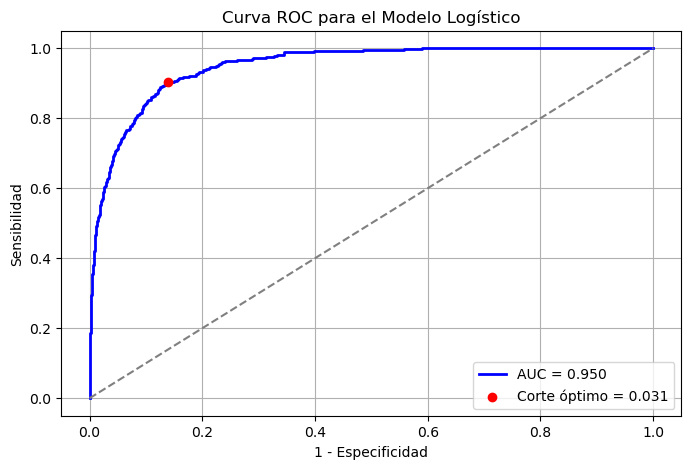

In [ ]:
fig, ax = plt.subplots()
ax.plot(fpr, tpr, color="blue", linewidth=2, label=f"AUC = {auc_m2:.3f}")
ax.scatter(fpr[best_idx], tpr[best_idx], color="red", zorder=3, label=f"Corte óptimo = {best_threshold:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("1 - Especificidad")
ax.set_ylabel("Sensibilidad")
ax.set_title("Curva ROC para el Modelo Logístico")
ax.legend(loc="lower right")
plt.show()

De la gráfica es posible observar que aquel punto de corte óptimo que maximiza la curva es cercano a 0.031, con un AUC cercano a 0.950, lo cual indica una buena clasificación y capacidad predictiva del modelo.


## 4.2.2 Matriz de confusión

Ya determinado el punto de corte óptimo, podemos ver la matriz de confusión asociada, a través de las siguientes sentencias.


In [ ]:
# Usamos el punto de corte óptimo calculado anteriormente.
pred_op = np.where(pred_m2 > best_threshold, "Yes", "No")
real = datos1["default"].astype(str)

mconf = pd.crosstab(
    pd.Series(pred_op, name="Predicho"),
    pd.Series(real, name="Real"),
).reindex(index=["No", "Yes"], columns=["No", "Yes"])

mconf

Real,No,Yes
Predicho,,
No,8325,33
Yes,1342,300


Recordemos que la matriz de confusión está compuesta por las siguientes celdas, considerando Yes como clase positiva:

|                | Estimado (No)        | Estimado (Yes)     |
|----------------|----------------------|--------------------|
| Real (No)      | Verdadero negativo   | Falso negativo     |
| Real (Yes)     | Falso positivo       | Verdadero positivo |

Y las fórmulas para sensibilidad y especificidad son las siguientes:

\begin{equation}
\begin{aligned}
\text{Sensibilidad} &= \frac{\text{VP}}{\text{VP} + \text{FN}} \\
\text{Especificidad} &= \frac{\text{VN}}{\text{VN} + \text{FP}}
\end{aligned}
\end{equation}


In [ ]:
# Con la tabla en formato Predicho x Real:
vp = mconf.loc["Yes", "Yes"]
fn = mconf.loc["No", "Yes"]
vn = mconf.loc["No", "No"]
fp = mconf.loc["Yes", "No"]

sens = vp / (vp + fn)
esp = vn / (vn + fp)

pd.DataFrame({
    "medida": ["Sensibilidad", "Especificidad"],
    "valor": [sens, esp],
})

,medida,valor
0,Sensibilidad,0.900901
1,Especificidad,0.861177


Luego, con los resultados de la tabla tenemos que:

\begin{equation}
\begin{aligned}
\text{Sensibilidad} &= \frac{\text{301}}{\text{301} + \text{32}}= 0.9039\\
\text{Especificidad} &= \frac{\text{8318}}{\text{8318} + \text{301}}=0.8605
\end{aligned}
\end{equation}

El modelo presenta una alta sensibilidad (0.9039), lo que indica una gran capacidad para identificar correctamente los casos de default. Asimismo, muestra una especificidad de 0.8605, evidenciando un buen desempeño al clasificar correctamente los casos de no default, aunque con cierta proporción de falsos positivos.

Por otro lado, es posible visualizar resultados equivalentes a la función `confusionMatrix` de la librería `caret` mediante `classification_report()`.


In [ ]:
print(classification_report(real, pred_op, labels=["No", "Yes"]))

              precision    recall  f1-score   support

          No       1.00      0.86      0.92      9667
         Yes       0.18      0.90      0.30       333

    accuracy                           0.86     10000
   macro avg       0.59      0.88      0.61     10000
weighted avg       0.97      0.86      0.90     10000



# 5. Bibliografía

- James, G., Witten, D., Hastie, T., and Tibshirani, R. (2013). *An Introduction to Statistical Learning with applications in R*. Springer-Verlag, New York. https://www.statlearning.com
- Siebert P. (1987). “Vehicle Recognition Using Rule Based Methods.” Turing Institute Research Memorandum TIRM-87-018.
- Blake C. L., Merz C. J. (1998). “UCI Repository of Machine Learning Databases.” University of California, Irvine, Department of Information and Computer Science.
- https://rpubs.com/joaquin_ar/229736
